# Atoms and calculators

This notebook follows the [official ASE tutorial](https://docs.ase-lib.org/examples_generated/01-gettingstarted/01-atoms-and-calculators.html). It introduces the two objects at the center of an ASE calculation: an `Atoms` object that describes a structure and a calculator that supplies energies, forces, and other properties.

The final goal is to sample the binding curve $E(d)$ of an $N_2$ molecule as a function of its internuclear distance $d$. Along the way, the notebook visualizes and saves structures, responds to coordinate changes, records a trajectory, and extracts a model dissociation energy. Positions and distances are in ångström (Å), energies in electronvolts (eV), and forces in eV/Å.

## Atoms: define and inspect a molecule

An `Atoms` object combines chemical symbols with Cartesian coordinates and, when needed, a simulation cell and periodic-boundary settings. The `positions` argument is a two-by-three array: each row belongs to one atom, and the columns are its $x$, $y$, and $z$ coordinates.

The two nitrogen atoms are placed at $z=-1$ Å and $z=1$ Å, giving an initial separation of 2 Å along the $z$ axis. No cell or periodic boundaries are specified, so ASE treats the molecule as an isolated, nonperiodic system. The inline X3D viewer provides a quick check of the geometry before any calculation is performed.

In [1]:
from ase import Atoms

atoms = Atoms('N2', positions=[[0, 0, -1], [0, 0, 1]])

In [2]:
from ase.visualize import view
view(atoms, viewer="x3d")

In [3]:
from ase.io import write

write('../files/tutorial_02/myatoms.traj', atoms)

### Saving and opening the structure

`ase.io.write()` infers the file format from `.traj` and writes the molecule in ASE's native trajectory format. This format can retain ASE-specific structural information and is also able to store multiple configurations.

From the repository root, open this structure in the desktop GUI with:

```bash
ase gui files/tutorial_02/myatoms.traj
```

The path differs from the one in the code cell because that cell is resolved relative to the notebook's working directory.

## Calculators: energy and forces

An `Atoms` object defines geometry but does not by itself provide a potential-energy model. Assigning `EMT()` to `atoms.calc` connects the structure to ASE's effective-medium theory calculator. EMT is inexpensive and useful for learning the calculator interface, but its $N_2$ values should be interpreted as model results rather than high-accuracy molecular predictions.

`get_potential_energy()` returns one total energy in eV. `get_forces()` returns a two-by-three array in eV/Å, with one Cartesian force vector per atom. Forces are the negative gradient of the potential energy with respect to atomic position:

$$
F_i = -∇_{r_i} E
$$

For this linear, symmetric molecule, the printed forces have equal magnitude and opposite $z$ components. `implemented_properties` lists the quantities that this calculator exposes through ASE's common interface.

In [4]:
from ase.calculators.emt import EMT

calc = EMT()
atoms.calc = calc

In [5]:
e = atoms.get_potential_energy()
print('Energy', e)
f = atoms.get_forces()
print('Forces', f)

Energy 6.1239042559302534
Forces [[ 0.          0.          5.36544175]
 [ 0.          0.         -5.36544175]]


In [6]:
print(EMT.implemented_properties)

['energy', 'free_energy', 'energies', 'forces', 'stress', 'magmom', 'magmoms']


## Binding curve of $N_2$

`atoms.positions` is a NumPy array, so individual coordinates can be inspected and changed directly. Moving atom 0 by $+0.1$ Å along $z$ shortens the separation from 2.0 Å to 1.9 Å.

ASE detects that the geometry has changed and invalidates calculator results tied to the old coordinates. The next requests for energy and forces therefore trigger a new EMT evaluation without requiring the calculator to be attached again. The lower energy after this displacement indicates that the original 2 Å geometry lies on the attractive side of this model's binding curve.

In [7]:
print(atoms.positions)

[[ 0.  0. -1.]
 [ 0.  0.  1.]]


In [8]:
atoms.positions[0, 2] += 0.1  # z-coordinate change of atom 0
e = atoms.get_potential_energy()
print('Energy', e)
f = atoms.get_forces()
print('Forces', f)

Energy 5.561108500221476
Forces [[ 0.          0.          5.88823349]
 [ 0.          0.         -5.88823349]]


### Saving calculated configurations

A trajectory can store both atomic configurations and calculator results such as energy and forces. Opening `Trajectory` in write mode creates a new file, while the context manager closes it cleanly after the frame is written. This separation makes it possible to generate calculations first and analyze them in a later step.

In [9]:
from ase.io.trajectory import Trajectory

with Trajectory('../files/tutorial_02/mytrajectory.traj', 'w') as traj:
    traj.write(atoms)

### Sampling $E(d)$

The scan rebuilds the molecule, attaches a fresh EMT calculator, and evaluates 60 separations from 0.5 Å to 6.4 Å in increments of 0.1 Å. Atom 0 remains fixed while atom 1 is repositioned along $z$, so the coordinate difference is the internuclear distance $d$.

At short distance the energy rises steeply and the forces push the atoms apart. Near the minimum, the force approaches zero. At large distance the interaction vanishes in this model and the energy approaches the separated-atom limit. Every geometry and its calculated properties are appended to `binding_curve.traj`.

In [11]:
atoms = Atoms('N2', positions=[[0, 0, -1], [0, 0, 1]])

calc = EMT()
atoms.calc = calc

step = 0.1
nsteps = int(6 / step)

with Trajectory('../files/tutorial_02/binding_curve.traj', 'w') as traj:
    for i in range(nsteps):
        d = 0.5 + i * step
        atoms.positions[1, 2] = atoms.positions[0, 2] + d

        e = atoms.get_potential_energy()
        f = atoms.get_forces()
        print('distance, energy', d, e)
        print('force', f)
        traj.write(atoms)

distance, energy 0.5 9.870758556485448
force [[  0.           0.         -52.28823918]
 [  0.           0.          52.28823918]]
distance, energy 0.6 5.5891182020987875
force [[  0.           0.         -34.25676672]
 [  0.           0.          34.25676672]]
distance, energy 0.7 2.8596713200020494
force [[  0.           0.         -21.02820162]
 [  0.           0.          21.02820162]]
distance, energy 0.8 1.2619022218412255
force [[  0.           0.         -11.45544942]
 [  0.           0.          11.45544942]]
distance, energy 0.9 0.47657850003904656
force [[ 0.          0.         -4.64947593]
 [ 0.          0.          4.64947593]]
distance, energy 1.0 0.262852687667797
force [[ 0.          0.          0.07663707]
 [ 0.          0.         -0.07663707]]
distance, energy 1.1 0.440343573035614
force [[ 0.          0.          3.25179997]
 [ 0.          0.         -3.25179997]]
distance, energy 1.2000000000000002 0.8751414634853774
force [[ 0.        0.        5.281651]
 [ 0.    

### Reading trajectory frames

`iread()` yields one configuration at a time instead of loading the entire trajectory into memory. Because the trajectory contains stored calculator results, `get_potential_energy()` retrieves each saved energy without rerunning EMT, provided the geometry is not modified.

> **Rerun note:** the following cell currently passes an empty filename to `iread()`. Supply `../files/tutorial_02/binding_curve.traj` before executing it again; its displayed output cannot be reproduced from the current source as written.

In [12]:
from ase.io import iread

for atoms in iread(''):
    print(atoms.get_potential_energy())

9.870758556485448
5.5891182020987875
2.8596713200020494
1.2619022218412255
0.47657850003904656
0.262852687667797
0.440343573035614
0.8751414634853774
1.4689017306321919
2.1503656496757095
2.8687861585156504
3.588846100007662
4.286743654814872
4.947188703592237
5.561108500221475
6.1239042559302534
6.634134384874031
7.092527120173083
7.501246466384996
7.863352195013119
8.18240775547698
8.46220031276367
8.706545228262538
8.919153642872061
9.103546774571704
9.263004401897888
9.40053800411676
9.518881353341813
9.620493149523368
9.707567671426157
9.782050476255852
9.845656988982057
9.899892435802158
9.946072038657272
9.985340733744675
10.018691933526325
10.046985039824794
10.070961551568727
10.091259707272991
10.108427669212126
10.122935301026965
10.135184619084068
10.14551901563504
10.154231370550555
10.16157126835245
10.16775243017553
10.172969623589921
10.177507006847515
10.18252838152903
10.191037181243342
10.197610791147888
10.199490793232709
10.199895789175132
10.199978991085064
10.2
1

### Plotting the curve and estimating dissociation energy

The analysis collects each saved energy and reconstructs $d$ from the difference between the two $z$ coordinates. This is valid here because the molecule remains aligned with the $z$ axis throughout the scan.

The dissociation energy is estimated from the last, widely separated configuration and the lowest sampled energy:

$$
D_e ≈ E(d_{max}) - min_d E(d)
$$

The reported value, approximately 9.94 eV, is an EMT result on a finite 0.1 Å grid. It uses the final scan point as the separated-atom limit and does not include zero-point vibrational energy or thermal corrections.

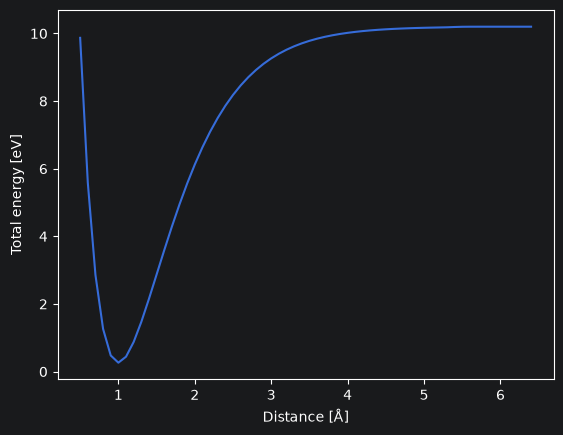

Dissociation energy [eV]:  9.937147312332202


In [13]:
import matplotlib.pyplot as plt

energies = []
distances = []

for atoms in iread('../files/tutorial_02/binding_curve.traj'):
    energies.append(atoms.get_potential_energy())
    distances.append(atoms.positions[1, 2] - atoms.positions[0, 2])

ax = plt.gca()
ax.plot(distances, energies)
ax.set_xlabel('Distance [Å]')
ax.set_ylabel('Total energy [eV]')
plt.show()

print('Dissociation energy [eV]: ', energies[-1] - min(energies))

## Takeaways and possible extensions

This example demonstrates ASE's central division of responsibility: `Atoms` owns the structure, while a calculator evaluates physical properties for that structure. Geometry changes invalidate stale results, and trajectory files connect calculation, visualization, and analysis without repeating completed work.

Useful extensions include refining the distance grid around the energy minimum, locating the equilibrium bond length with an optimizer, comparing `read()` with `iread()`, and repeating the curve with a calculator designed for quantitative molecular energetics.